In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import glob
import os,sys
import fitsio as fio
from tqdm import tqdm
import proplot as pplt
import pickle
import glob
from astropy.io import fits
from scipy.optimize import curve_fit
import healsparse
import healpy as hp
import pandas as pd
from math import log10
import healsparse as hsp
import skyproj
from des_y6utils import mdet
import h5py as h5

%matplotlib inline
matplotlib.rcParams.update({'font.size': 20})

In [8]:
def read_mdet_h5(datafile, gal_weight_file, keys, mdet_step, patch_id=None, response=False, subtract_mean_shear=False, subtract_shear_color=False):

    def assign_loggrid(x, y, xmin, xmax, xsteps, ymin, ymax, ysteps):
        """
        Computes indices of 2D grids. Only used when we use shear weight that is binned by S/N and size ratio. 
        """
        from math import log10
        # return x and y indices of data (x,y) on a log-spaced grid that runs from [xy]min to [xy]max in [xy]steps

        logstepx = log10(xmax/xmin)/xsteps
        logstepy = log10(ymax/ymin)/ysteps

        indexx = (np.log10(x/xmin)/logstepx).astype(int)
        indexy = (np.log10(y/ymin)/logstepy).astype(int)

        indexx = np.maximum(indexx,0)
        indexx = np.minimum(indexx, xsteps-1)
        indexy = np.maximum(indexy,0)
        indexy = np.minimum(indexy, ysteps-1)

        return indexx,indexy

    def assign_grid(x, y, xmin, xmax, xsteps, ymin, ymax, ysteps):
        # return x and y indices of data (x,y) on a log-spaced grid that runs from [xy]min to [xy]max in [xy]steps
        
        xbins=np.linspace(xmin, xmax, xsteps+1)
        ybins=np.linspace(ymin, ymax, ysteps+1)

        indexx=np.digitize(x, xbins, right=True)
        indexy=np.digitize(y, ybins, right=True)

        indexx = indexx - 1
        indexy = indexy - 1

        indexx = np.maximum(indexx,0)
        indexx = np.minimum(indexx, xsteps-1)
        indexy = np.maximum(indexy,0)
        indexy = np.minimum(indexy, ysteps-1)

        return indexx,indexy

    def _find_shear_weight(dat, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, mdet_mom):

        """
        Assigns shear weights to the objects based on the grids. 
        """
        
        if wgt_dict is None:
            weights = np.ones(len(dat))
            return weights

        shear_wgt = wgt_dict['weight']
        smoothing = True
        if smoothing:
            from scipy.ndimage import gaussian_filter
            smooth_response = gaussian_filter(wgt_dict['response'], sigma=2.0)
            shear_wgt = (smooth_response/wgt_dict['meanes'])**2
        indexx, indexy = assign_loggrid(np.array(dat[mdet_mom+'_s2n'])[mask], np.array(dat[mdet_mom+'_T_ratio'])[mask], snmin, snmax, steps, sizemin, sizemax, steps)
        weights = np.array([shear_wgt[x, y] for x, y in zip(indexx, indexy)])
        
        return weights

    def _get_shear_weights(dat, mask, gal_weight_file, shape_err=False):
        if shape_err:
            return 1/(0.22**2 + 0.5*(np.array(dat['gauss_g_cov_1_1'])[mask] + np.array(dat['gauss_g_cov_2_2'])[mask]))
        else:
            with open(gal_weight_file, 'rb') as handle:
                wgt_dict = pickle.load(handle)
                snmin = wgt_dict['xedges'][0]
                snmax = wgt_dict['xedges'][-1]
                sizemin = wgt_dict['yedges'][0]
                sizemax = wgt_dict['yedges'][-1]
                steps = len(wgt_dict['xedges'])-1
            shear_wgt = _find_shear_weight(dat, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, 'gauss')
            return shear_wgt

    def _wmean(q,w):
        return np.sum(q*w)/np.sum(w)
    
    import h5py as h5
    f = h5.File(datafile, 'r')
    d = f.get('/mdet/'+mdet_step)
    if patch_id is None:
        nrows = len(np.array( d['ra'] ))
        mask = np.ones(nrows)!=0
    else:
        mask = (np.array( d['patch_num'] ) == patch_id)
        nrows = len(np.array( d['ra'] )[mask])
    formats = []
    for key in keys:
        formats.append('f4')
    data = np.recarray(shape=(nrows,), formats=formats, names=keys)
    for key in keys:  
        if key == 'w':
            data['w'] = _get_shear_weights(d, mask, gal_weight_file)
        elif key in ('g1', 'g2'):
            data[key] = np.array(d['gauss_'+key[0]+'_'+key[1]])[mask]
        elif key == 'gauss_T':
            data[key] = np.array(d['gauss_psf_T'])[mask] * np.array(d['gauss_T_ratio'])[mask]
        elif key == 'gmi':
            mag_g = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_g"])[mask], 0)
            mag_i = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_i"])[mask], 2)
            data[key] = mag_g - mag_i
        elif key == 'imz':
            mag_i = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_i"])[mask], 2)
            mag_z = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_z"])[mask], 3)
            data[key] = mag_i - mag_z
        else:
            data[key] = np.array(d[key])[mask]
    # print('made recarray with hdf5 file')
    
    # response correction
    if response:
        d_2p = f.get('/mdet/2p')
        d_1p = f.get('/mdet/1p')
        d_2m = f.get('/mdet/2m')
        d_1m = f.get('/mdet/1m')
        # compute response with weights
        g1p = _wmean(np.array(d_1p["gauss_g_1"]), _get_shear_weights(d_1p, gal_weight_file))                                     
        g1m = _wmean(np.array(d_1m["gauss_g_1"]), _get_shear_weights(d_1m, gal_weight_file))
        R11 = (g1p - g1m) / 0.02

        g2p = _wmean(np.array(d_2p["gauss_g_2"]), _get_shear_weights(d_2p, gal_weight_file))
        g2m = _wmean(np.array(d_2m["gauss_g_2"]), _get_shear_weights(d_2m, gal_weight_file))
        R22 = (g2p - g2m) / 0.02

        R = (R11 + R22)/2.
        data['g1'] /= R
        data['g2'] /= R

        mean_g1 = _wmean(data['g1'], data['w'])
        mean_g2 = _wmean(data['g2'], data['w'])
        std_g1 = np.var(data['g1'])
        std_g2 = np.var(data['g2'])
        mean_shear = [mean_g1, mean_g2, std_g1, std_g2]
        # mean shear subtraction
        if subtract_mean_shear:
            print('subtracting mean shear')
            print('mean g1 g2 =(%1.8f,%1.8f)'%(mean_g1, mean_g2))          
            data['g1'] -= mean_g1
            data['g2'] -= mean_g2

    return data

def _compute_g1_g2(res, binnum, method='all', tile=None):

    # Compute mean shear with response. 
    # For 'jk' and 'tile', it is calculating mean shear for each jackknife sample/each tile. 
    # For 'all', it is computing mean shear from res['all'] which sums all the shears in all the catalogs. 

    corrected_g1g2 = np.zeros((binnum, 2))
    for bin in range(binnum):
        if method == 'jk':
            g1 = res['noshear'][bin][0] / res['num_noshear'][bin][0]
            g1p = res['1p'][bin][0] / res['num_1p'][bin][0]
            g1m = res['1m'][bin][0] / res['num_1m'][bin][0]
            R11 = (g1p - g1m) / 2 / 0.01

            g2 = res['noshear'][bin][1] / res['num_noshear'][bin][1]
            g2p = res['2p'][bin][1] / res['num_2p'][bin][1]
            g2m = res['2m'][bin][1] / res['num_2m'][bin][1]
            R22 = (g2p - g2m) / 2 / 0.01
        
        elif method == 'tile':
            g1 = res[tile]['noshear'][bin][0] / res[tile]['num_noshear'][bin][0]
            g1p = res[tile]['1p'][bin][0] / res[tile]['num_1p'][bin][0]
            g1m = res[tile]['1m'][bin][0] / res[tile]['num_1m'][bin][0]
            R11 = (g1p - g1m) / 2 / 0.01

            g2 = res[tile]['noshear'][bin][1] / res[tile]['num_noshear'][bin][1]
            g2p = res[tile]['2p'][bin][1] / res[tile]['num_2p'][bin][1]
            g2m = res[tile]['2m'][bin][1] / res[tile]['num_2m'][bin][1]
            R22 = (g2p - g2m) / 2 / 0.01

        elif method == 'all':
            g1 = res['noshear'][bin][0] / res['num_noshear'][bin][0]
            g1p = res['1p'][bin][0] / res['num_1p'][bin][0]
            g1m = res['1m'][bin][0] / res['num_1m'][bin][0]
            R11 = (g1p - g1m) / 2 / 0.01

            g2 = res['noshear'][bin][1] / res['num_noshear'][bin][1]
            g2p = res['2p'][bin][1] / res['num_2p'][bin][1]
            g2m = res['2m'][bin][1] / res['num_2m'][bin][1]
            R22 = (g2p - g2m) / 2 / 0.01

        corrected_g1g2[bin, 0] = g1/R11
        corrected_g1g2[bin, 1] = g2/R22
    return corrected_g1g2

def _compute_shear_per_jksample(res_jk, res, ith_tilename, tilenames, binnum):

    # Compute mean shear for each jackknife sample. 
    # For each jackknife sample, you leave one tile out, sums the shears in N-1 tiles, and compute the mean. 
    
    for t in tilenames:
        if t == ith_tilename:
            continue
        else:
            for step in ['noshear', '1p', '1m', '2p', '2m']:
                
                for bin in range(binnum):
                    np.add.at(
                        res_jk[step], 
                        (bin, 0), 
                        res[t][step][bin][0],
                    )
                    np.add.at(
                        res_jk[step], 
                        (bin, 1), 
                        res[t][step][bin][1],
                    )
                    np.add.at(
                        res_jk["num_" + step], 
                        (bin, 0), 
                        res[t]["num_" + step][bin][0],
                    )
                    np.add.at(
                        res_jk["num_" + step], 
                        (bin, 1), 
                        res[t]["num_" + step][bin][1],
                    )
    jk_sample_mean = _compute_g1_g2(res_jk, binnum, method='jk')
    return jk_sample_mean

def _accum_shear_per_tile(res, dat, key, bin_low, bin_high, binnum):
    
    for i,step in enumerate(['noshear', '1p', '1m', '2p', '2m']):
        g1_masked = dat[i]['g1'] * dat[i]['w']
        g2_masked = dat[i]['g2'] * dat[i]['w']
        qa_masked = dat[i][key]
        
        for bin in range(binnum):
            msk_bin = np.where(((qa_masked >= bin_low[bin]) & (qa_masked <= bin_high[bin])))[0]
            np.add.at(
                res[step], 
                (bin, 0), 
                np.sum(g1_masked[msk_bin]),
            )
            np.add.at(
                res[step], 
                (bin, 1), 
                np.sum(g2_masked[msk_bin]),
            )
            np.add.at(
                res["num_" + step], 
                (bin, 0), 
                np.sum(dat[i]['w'][msk_bin]),
            )
            np.add.at(
                res["num_" + step], 
                (bin, 1), 
                np.sum(dat[i]['w'][msk_bin]),
            )
    
    return res

def _accum_shear_all(res, binnum):

    # Sum all the raw sums in each tile. 
    res_accum = {'noshear': np.zeros((binnum, 2)), 'num_noshear': np.zeros((binnum, 2)), 
            '1p': np.zeros((binnum, 2)), 'num_1p': np.zeros((binnum, 2)), 
            '1m': np.zeros((binnum, 2)), 'num_1m': np.zeros((binnum, 2)),
            '2p': np.zeros((binnum, 2)), 'num_2p': np.zeros((binnum, 2)),
            '2m': np.zeros((binnum, 2)), 'num_2m': np.zeros((binnum, 2))}
    for tilename in res.keys():
        for step in ['noshear', '1p', '1m', '2p', '2m']:
            
            for bin in range(binnum):
                np.add.at(
                    res_accum[step], 
                    (bin, 0), 
                    res[tilename][step][bin][0],
                )
                np.add.at(
                    res_accum[step], 
                    (bin, 1), 
                    res[tilename][step][bin][1],
                )
                np.add.at(
                    res_accum["num_" + step], 
                    (bin, 0), 
                    res[tilename]["num_" + step][bin][0],
                )
                np.add.at(
                    res_accum["num_" + step], 
                    (bin, 1), 
                    res[tilename]["num_" + step][bin][1],
                )
    return res_accum

def _compute_jackknife_error_estimate(res_jk_mean, binnum, N):

    jk_cov = np.zeros((binnum, 2))
    for bin in range(binnum):
        # compute jackknife average. 
        jk_g1_ave = np.array([res_jk_mean[sample][bin][0] for sample in list(res_jk_mean)])
        jk_all_g1_ave = np.mean(jk_g1_ave)
        jk_g2_ave = np.array([res_jk_mean[sample][bin][1] for sample in list(res_jk_mean)])
        jk_all_g2_ave = np.mean(jk_g2_ave)

        # cov_g1 = np.sqrt((N-1)/N)*np.sqrt(np.sum((jk_g1_ave - res_all_mean[bin][0])**2))
        # cov_g2 = np.sqrt((N-1)/N)*np.sqrt(np.sum((jk_g2_ave - res_all_mean[bin][1])**2))
        cov_g1 = np.sqrt((N-1)/N)*np.sqrt(np.sum((jk_g1_ave - jk_all_g1_ave)**2))
        cov_g2 = np.sqrt((N-1)/N)*np.sqrt(np.sum((jk_g2_ave - jk_all_g2_ave)**2))

        jk_cov[bin, 0] = cov_g1
        jk_cov[bin, 1] = cov_g2

    return jk_cov


def function(input_, mdet_files, wgt_file, outpath):

    [key,pname,bins,binnum] = input_
    
    # if key == 'gmi':
    #     keys = ['g1', 'g2', 'w', 'imz', key]
    # elif key == 'imz':
    #     keys = ['g1', 'g2', 'w', 'gmi', key]
    # else:
    #     keys = ['g1', 'g2', 'w', 'gmi', 'imz', key]
    keys = ['g1', 'g2', 'w', 'gmi', key]
    subtract_color = False # option to subtract mean shear from color grid
    d = read_mdet_h5(mdet_files, wgt_file, keys, 'noshear', patch_id=pname, response=False, subtract_mean_shear=True, subtract_shear_color=subtract_color)
    d_1p = read_mdet_h5(mdet_files, wgt_file, keys, '1p', patch_id=pname, response=False, subtract_mean_shear=True, subtract_shear_color=subtract_color)
    d_1m = read_mdet_h5(mdet_files, wgt_file, keys, '1m', patch_id=pname, response=False, subtract_mean_shear=True, subtract_shear_color=subtract_color)
    d_2p = read_mdet_h5(mdet_files, wgt_file, keys, '2p', patch_id=pname, response=False, subtract_mean_shear=True, subtract_shear_color=subtract_color)
    d_2m = read_mdet_h5(mdet_files, wgt_file, keys, '2m', patch_id=pname, response=False, subtract_mean_shear=True, subtract_shear_color=subtract_color)
    d_all = [d, d_1p, d_1m, d_2p, d_2m]
    # msk = mdet._make_mdet_cuts_gauss(d, n_terr=3) # if you need max_t cut, add it here. max_t = 0.689 (top 25% cut) for gauss, 0.466 for pgauss. 
    
    ## ADD ADDITIONAL CUTS HERE. (e.g., size, color selections)
    # color splits: blue-[-2.00, 0.76], mid-[0.76, 1.49], red-[1.49, 4.00]
    # size splits: small-[0.095, 0.301], midsize-[0.301, 0.455], large-[0.454, 8000]
    # size S/N splits: bad-[1.63e-4, 7.30], ok-[7.30, 15], good-[15-35361]
    # dcut = flux2mag(d['pgauss_band_flux_g']) - flux2mag(d['pgauss_band_flux_i'])
    # dcut = (d['gauss_T_ratio'] * d["gauss_psf_T"]) * d['gauss_T_err']
    # dcut2 = (d['gauss_T_ratio'] * d["gauss_psf_T"])/d['gauss_T_err']
    # dmin = 1.49
    # dmax = 4.00
    # for i,cat in enumerate(d_all):
    #     d_all[i] = cat[((cat['gmi'] > dmin) & (cat['gmi'] < dmax))] 
    
    
    res = {'noshear': np.zeros((binnum, 2)), 'num_noshear': np.zeros((binnum, 2)), 
            '1p': np.zeros((binnum, 2)), 'num_1p': np.zeros((binnum, 2)), 
            '1m': np.zeros((binnum, 2)), 'num_1m': np.zeros((binnum, 2)),
            '2p': np.zeros((binnum, 2)), 'num_2p': np.zeros((binnum, 2)),
            '2m': np.zeros((binnum, 2)), 'num_2m': np.zeros((binnum, 2))}
    res = _accum_shear_per_tile(res, d_all, key, bins['low'], bins['high'], binnum)

    output_fpath = os.path.join(outpath, '{0}_{1}'.format(key,pname)+'.pickle')
    with open(output_fpath, 'wb') as fp:
        pickle.dump(res, fp, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
mdet_files = '/global/cfs/cdirs/des/y6-image-sims/fiducial/g1_slice=-0.02__g2_slice=0.00__g1_other=0.00__g2_other=0.00__zlow=0.0__zhigh=6.0/metadetect_cutsv6_all.h5'
wgt_file = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/inverse_variance_weight_v6.pickle'
keys = ['psfrec_g_1', 'psfrec_g_2', 'psfrec_T']
bin_file = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/mean_shear_measurement/mean_shear_bin_final_v6_weighted.pickle'
measurement_file = 'imsim_measurement.pickle'
outpath = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/imsims'

In [4]:
fids = np.arange(200)
with open(bin_file, 'rb') as handle:
    bin_dict = pickle.load(handle)
runs = []
for key in tqdm(keys):
    for pname in fids:
        bins = bin_dict[key]
        binnum = len(bins['hist'])
        runs.append([key,pname,bins,binnum])
handle.close()

for i in tqdm(range(len(runs))):
    function(runs[i], mdet_files, wgt_file, outpath)

 75%|███████▌  | 600/800 [39:19<13:06,  3.93s/it]  


ValueError: Duplicate field names: ['gmi']

In [15]:
measurement_result = {}
bins_tmp = [runs[0][2], runs[200][2], runs[400][2]]
binnum_tmp = [runs[0][3], runs[200][3], runs[400][3]]
for k,key in enumerate(keys):
    print(key)
    bins = bins_tmp[k]# bin_dict[key]
    binnum = binnum_tmp[k] # len(bins['hist'])
    res_all = {}
    res_jk_mean = {} 

    fpath = os.path.join(outpath, f"""{key}_*.pickle""")
    res_files = sorted(glob.glob(fpath))
    for idx,fname in zip(fids, res_files):
        with open(fname, 'rb') as f:
            d = pickle.load(f)
        res_all[idx] = d

    # copmute mean shear by combining all the files.
    res_accum = _accum_shear_all(res_all, binnum)
    print('number of objects is: ', np.sum(res_accum['num_noshear'], axis=0))
    # Compute the mean g1 and g2 over all the tiles. 
    res_all_mean = _compute_g1_g2(res_accum, binnum)

    print('computing jackknife covariance...')
    for sample,pname in tqdm(enumerate(res_all.keys())):
        res_jk = {'noshear': np.zeros((binnum, 2)), 'num_noshear': np.zeros((binnum, 2)), 
                    '1p': np.zeros((binnum, 2)), 'num_1p': np.zeros((binnum, 2)), 
                    '1m': np.zeros((binnum, 2)), 'num_1m': np.zeros((binnum, 2)),
                    '2p': np.zeros((binnum, 2)), 'num_2p': np.zeros((binnum, 2)),
                    '2m': np.zeros((binnum, 2)), 'num_2m': np.zeros((binnum, 2))}

        jk_sample_mean = _compute_shear_per_jksample(res_jk, res_all, pname, fids, binnum)
        res_jk_mean[sample] = jk_sample_mean

    # Write out res_jk_mean in pickle file.
    with open(os.path.join(outpath, 'res_jk_mean.pickle'), 'wb') as handle:
        pickle.dump(res_jk_mean, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # Compute jackknife error estimate.
    jk_error = _compute_jackknife_error_estimate(res_jk_mean, binnum, len(fids))
    measurement_result[key] = {'bin_mean': bins['mean'], 'g1': res_all_mean[:,0], 'g2': res_all_mean[:,1], 'g1_cov': jk_error[:,0], 'g2_cov': jk_error[:,1]}

with open(os.path.join(outpath, measurement_file), 'wb') as handle:
    pickle.dump(measurement_result, handle, protocol=pickle.HIGHEST_PROTOCOL) 

psfrec_g_1


0it [00:00, ?it/s]

number of objects is:  [1.40996764e+08 1.40996764e+08]
computing jackknife covariance...


200it [00:57,  3.47it/s]


psfrec_g_2


...

200it [00:57,  3.50it/s]


psfrec_T


0it [00:00, ?it/s]

number of objects is:  [1.40997275e+08 1.40997275e+08]
computing jackknife covariance...


200it [00:57,  3.50it/s]


In [16]:
with open(os.path.join(outpath, measurement_file), 'rb') as f:
    d = pickle.load(f)

slope: -0.0079+-0.0054
slope: -0.0041+-0.0057


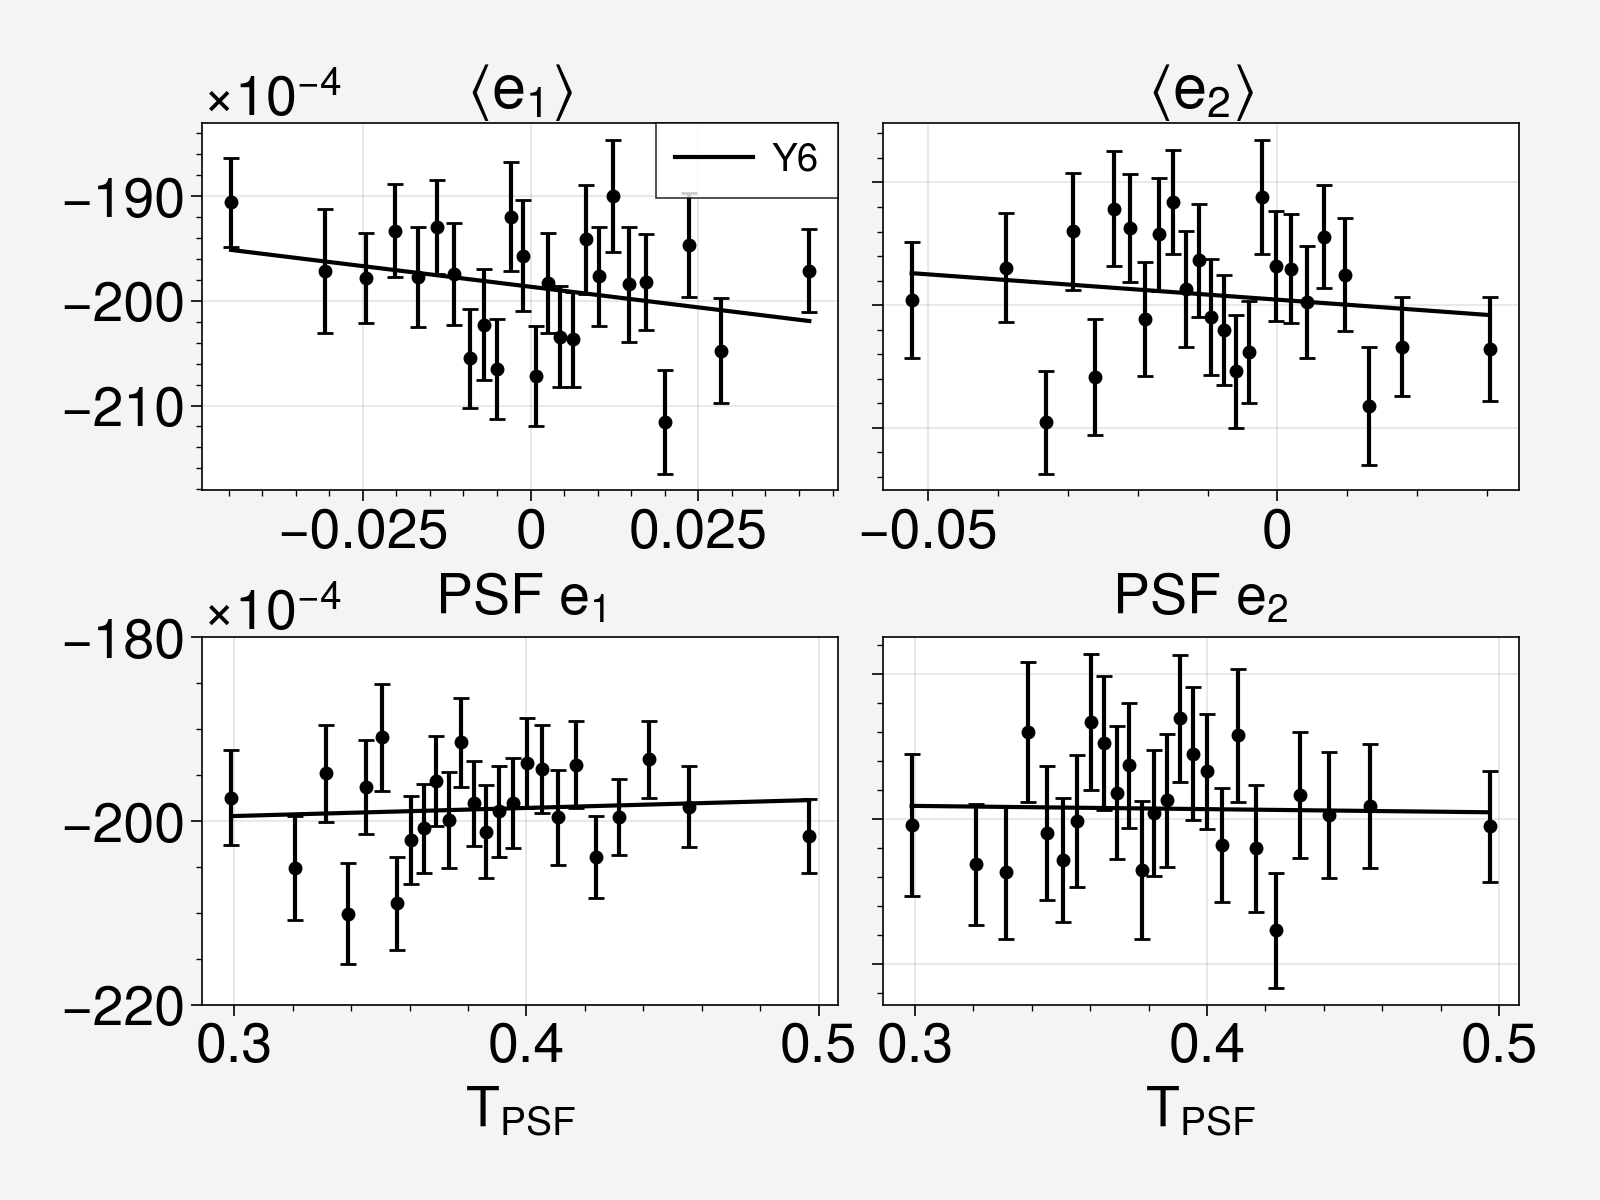

In [32]:
def _compute_OLSfit(x, y, dy=None):
    """Find the best fitting parameters of a linear fit to the data through the
    method of ordinary least squares estimation. (i.e. find m and b for
    y = m*x + b)
    Args:
        x: Numpy array of independent variable data
        y: Numpy array of dependent variable data. Must have same size as x.
        dy: Numpy array of dependent variable standard deviations. Must be same
            size as y.
    Returns: A list with four floating point values. [m, dm, b, db]
    """
    if dy is None:
        #if no error bars, weight every point the same
        dy = np.ones(x.size)
    denom = np.sum(1 / dy**2) * np.sum((x / dy)**2) - (np.sum(x / dy**2))**2
    m = (np.sum(1 / dy**2) * np.sum(x * y / dy**2) -
         np.sum(x / dy**2) * np.sum(y / dy**2)) / denom
    b = (np.sum(x**2 / dy**2) * np.sum(y / dy**2) -
         np.sum(x / dy**2) * np.sum(x * y / dy**2)) / denom
    
    dm = np.sqrt(np.sum(1 / dy**2) / denom)
    db = np.sqrt(np.abs(np.sum(x / dy**2) / denom))
    return m, dm, b, db

def generate_annot_text(dat, xlabel, ylabel, mean_shear):
    
    # x = np.linspace(dat[xlabel]['bin_mean'][0], dat[xlabel]['bin_mean'][-1], 50)
    # m,dm,b,db = _compute_OLSfit(dat[xlabel]['bin_mean'], dat[xlabel][ylabel], dy=dat[xlabel][ylabel+'_cov'])
    def func(x,m,b):
        return m*x + b
    x = dat[xlabel]['bin_mean']
    popt, pcov = curve_fit(func, x, dat[xlabel][ylabel]-mean_shear, sigma=dat[xlabel][ylabel+'_cov'])
    m,b = popt
    dm,db = np.sqrt(np.diag(pcov))
    reg = m*x + b
    
    text1 = "slope: "+"{:.4f}".format(m)+"+-"+"{:.4f}".format(dm)
    text2 = "offset: "+"{:.6f}".format(b)+"+-"+"{:.6f}".format(db)
        
    binnum = len(dat[xlabel]['bin_mean'])
    posx = dat[xlabel]['bin_mean'][0] #[binnum//2]
    posy = np.min(dat[xlabel][ylabel])-0.00010
    return x,reg,text1,text2,posx,posy

matplotlib.rcParams.update({'font.size': 20, 'legend.fontsize':'x-small', 'lines.markersize': 4})
layout = np.arange(4).reshape(2, 2)
fig,ax = plt.subplot_mosaic(layout, figsize=(8,6))

mean_e1 = 0
mean_e2 = 0

"""mean shear vs PSF shapes"""
ax[0].errorbar(d['psfrec_g_1']['bin_mean'], d['psfrec_g_1']['g1']-mean_e1, yerr=d['psfrec_g_1']['g1_cov'], fmt='o', c='k', ls='none')
x,reg,text1,text2,posx,posy = generate_annot_text(d, 'psfrec_g_1', 'g1', mean_e1)
# b_=d_e1_psfe1['mut'][0][0][0]
# ax[0].plot(d['psfrec_g_1']['bin_mean'], b_*(d['psfrec_g_1']['bin_mean']), ls='dashdot', c='r', alpha=0.7, label='Y3')
ax[0].plot(x, reg, c='k', label='Y6')
# ax[0].text(-0.035, -0.0185, text1, ha="left", va="center", size=12,)
print(text1)
ax[0].set_xlabel(r'PSF $e_1$')
ax[0].set_title(r'$\langle e_1 \rangle$')
# ax[0].set_xlim(-0.04, 0.04)
# ax[0].set_ylim(-0.022, -0.018)
ax[0].ticklabel_format(axis='y', style='sci', scilimits=(-4,-4))
ax[0].legend(ncol=2, loc='upper right')

ax[1].errorbar(d['psfrec_g_2']['bin_mean'], d['psfrec_g_2']['g2']-mean_e2, yerr=d['psfrec_g_2']['g2_cov'], fmt='o', c='k', ls='none')
x,reg,text1,text2,posx,posy = generate_annot_text(d, 'psfrec_g_2', 'g2', mean_e2)
# b_=d_e2_psfe2['mut'][0][0][0]
# ax[1].plot(d['psfrec_g_2']['bin_mean'], b_*(d['psfrec_g_2']['bin_mean']), ls='dashdot', alpha=0.7, c='r')
ax[1].plot(x, reg, c='k')
# ax[1].text(-0.05, -0.0185, text1, ha="left", va="center", size=12,)
print(text1)
ax[1].set_xlabel(r'PSF $e_2$')
ax[1].set_title(r'$\langle e_2 \rangle$')
# ax[1].set_xlim(-0.055, 0.04)
# ax[1].set_ylim(-0.0005, 0.0005)
ax[1].set_yticklabels([])


"""mean shear vs PSF size"""
ax[2].errorbar(d['psfrec_T']['bin_mean'], d['psfrec_T']['g1']-mean_e1, yerr=d['psfrec_T']['g1_cov'], fmt='o', c='k', ls='none')
x,reg,text1,text2,posx,posy = generate_annot_text(d, 'psfrec_T', 'g1', mean_e1)
# ax[2].plot(d['psfrec_T']['bin_mean'], reg_e1_Tpsf, ls='dashdot', alpha=0.7, c='r')
ax[2].plot(x, reg, c='k')
# ax[2].set_xscale('log')
# ax[2].text(0.3, -0.00052, text1, ha="left", va="center", size=12,)
ax[2].set_xlabel(r'$T_{\rm PSF}$')
# ax[2].set_ylabel(r'$\langle e_1 \rangle$')
ax[2].set_ylim(-0.022, -0.018)
ax[2].ticklabel_format(axis='y', style='sci', scilimits=(-4,-4))
# ax[2].set_xticks(np.array([0.5,1.0,1.5,2.0,2.5,3.,4.,5.]))
# ax[2].set_xticklabels(np.array(['0.5', r'1.0','',r'2.0','',r'3.0','', '5.0']))


ax[3].errorbar(d['psfrec_T']['bin_mean'], d['psfrec_T']['g2']-mean_e2, yerr=d['psfrec_T']['g2_cov'], fmt='o', c='k', ls='none')
x,reg,text1,text2,posx,posy = generate_annot_text(d, 'psfrec_T', 'g2', mean_e2)
# ax[3].plot(d['psfrec_T']['bin_mean'], reg_e2_Tpsf, ls='dashdot', alpha=0.7, c='r')
ax[3].plot(x, reg, c='k')
# ax[3].set_xscale('log')
# ax[3].text(0.3, -0.00052, text1, ha="left", va="center", size=12,)
ax[3].set_xlabel(r'$T_{\rm PSF}$')
# ax[3].set_ylabel(r'$\langle e_2 \rangle$')
# ax[3].set_ylim(-0.0008, 0.00075)
# ax[3].set_xticks(np.array([0.5,1.0,1.5,2.0,2.5,3.,4.,5.]))
# ax[3].set_xticklabels(np.array(['0.5', r'1.0','',r'2.0','',r'3.0','', '5.0']))
ax[3].set_yticklabels([])


plt.tight_layout()
fig.subplots_adjust(wspace=0.07, hspace=0.4)
# plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/mean_shear_stats_psfe1e2_psfT_Tgal.pdf', bbox_inches='tight')